# Chapter 8 — Determinants: Algebra and Geometry

Numerical companion to `notes.md`. We'll:

1. Compute `det` of a 2×2 and a 3×3 by hand formula, cofactor recursion, and `numpy.linalg.det` — all three should agree.
2. Implement **cofactor expansion** recursively from scratch (the textbook `O(n!)` formula — beautiful, slow).
3. Implement `det` by **LU decomposition** — the `O(n³)` practical algorithm.
4. Time both on a 10×10 matrix — LU wins by many orders of magnitude.
5. **Visualize** the unit square under a 2×2 transformation: area scales by `|det A|`, orientation flips when `det A < 0`.
6. **Visualize** the unit cube under a 3×3 transformation — volume scales by `|det A|`.
7. Demonstrate the effect of each elementary **row operation** on `det` — swap flips sign, scale multiplies, row-add leaves unchanged.
8. Verify **multiplicativity** `det(AB) = det(A) · det(B)` on random matrices.
9. Closed-form **Vandermonde** vs direct `det` — exact match.
10. Solve a 3×3 system by **Cramer's Rule** and cross-check against `numpy.linalg.solve`.
11. Compute the **adjugate** (classical adjoint) and verify `A · adj(A) = (det A) · I`.
12. Preview Ch 9 — eigenvalues via roots of `det(A − λI)`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(8)

## 1. Three ways to compute `det` for a small matrix

Take the anchor matrix from `notes.md`:

```
A = [[2, 1, 3],
     [1, 4, 2],
     [3, 2, 5]]
```

The first-row cofactor expansion gives `det A = 2·16 − 1·(−1) + 3·(−10) = 3`. Sarrus agrees. Row reduction to upper-triangular `U = diag(2, 7/2, 3/7)` gives the same: `2 · 7/2 · 3/7 = 3`.

In [2]:
A = np.array([[2, 1, 3],
              [1, 4, 2],
              [3, 2, 5]], dtype=float)

det_sarrus = (
    A[0,0]*A[1,1]*A[2,2] + A[0,1]*A[1,2]*A[2,0] + A[0,2]*A[1,0]*A[2,1]
    - A[0,2]*A[1,1]*A[2,0] - A[0,0]*A[1,2]*A[2,1] - A[0,1]*A[1,0]*A[2,2]
)
print(f'det A by Sarrus          = {det_sarrus}')
print(f'det A by numpy.linalg    = {np.linalg.det(A):.10f}')

det A by Sarrus          = 3.0
det A by numpy.linalg    = 3.0000000000


## 2. Cofactor recursion from scratch

The Leibniz formula is `n!`-expensive. The cofactor recursion is also super-polynomial — but it's a direct mirror of the definition and is lovely to implement:

In [3]:
def det_cofactor(M):
    '''det via the cofactor (Laplace) expansion along row 0.'''
    n = M.shape[0]
    if n == 1:
        return M[0, 0]
    if n == 2:
        return M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0]
    total = 0.0
    for j in range(n):
        minor = np.delete(np.delete(M, 0, axis=0), j, axis=1)
        total += (-1)**j * M[0, j] * det_cofactor(minor)
    return total


for k, Mat in enumerate([
    np.array([[3, 1], [1, 2]], dtype=float),
    A,
    np.array([[1, 2, 0, 0],
              [0, 3, 0, 0],
              [4, 5, 6, 0],
              [7, 8, 9, 2]], dtype=float),
]):
    my = det_cofactor(Mat)
    np_ = np.linalg.det(Mat)
    print(f'test {k+1}: cofactor={my:.4f}   numpy={np_:.4f}   match={np.isclose(my, np_)}')

test 1: cofactor=5.0000   numpy=5.0000   match=True
test 2: cofactor=3.0000   numpy=3.0000   match=True
test 3: cofactor=36.0000   numpy=36.0000   match=True


## 3. `det` via LU decomposition (the practical algorithm)

`numpy.linalg.det` doesn't expand cofactors. It computes `PA = LU` (row-permuted LU), reads the diagonal of `U`, and multiplies — corrected by `(−1)^{# row swaps}`. We'll do this ourselves.

In [4]:
from scipy.linalg import lu

def det_lu(M):
    '''det via PA = LU factorization — O(n^3).'''
    P, L, U = lu(M)
    # diag of U multiplied, sign correction from the permutation P
    sign = np.linalg.det(P)  # det of a permutation matrix is ±1 (cheap)
    return sign * np.prod(np.diag(U))


print(f'det_lu(A) = {det_lu(A):.6f}')
print(f'det_lu([3,1;1,2]) = {det_lu(np.array([[3,1],[1,2]], dtype=float)):.6f}')

det_lu(A) = 3.000000
det_lu([3,1;1,2]) = 5.000000


## 4. Timing: cofactor vs LU on a 10×10

The cofactor recursion makes `10! = 3.6M` multiplications. LU makes `~10^3/3 ≈ 333`. Let's measure.

In [5]:
M = rng.standard_normal((10, 10))

t0 = time.time()
d_cof = det_cofactor(M)
t_cof = time.time() - t0

t0 = time.time()
d_lu = det_lu(M)
t_lu = time.time() - t0

t0 = time.time()
d_np = np.linalg.det(M)
t_np = time.time() - t0

print(f'det cofactor = {d_cof:.6f}   time {t_cof*1000:.1f} ms')
print(f'det LU       = {d_lu:.6f}    time {t_lu*1000:.3f} ms')
print(f'det numpy    = {d_np:.6f}    time {t_np*1000:.3f} ms')
print(f'speedup LU vs cofactor: ~{t_cof / t_lu:.0f}×')

det cofactor = -61.820699   time 8015.5 ms
det LU       = -61.820699    time 0.127 ms
det numpy    = -61.820699    time 0.031 ms
speedup LU vs cofactor: ~63195×


## 5. Visualize: 2×2 transformations scale area

Apply three 2×2 matrices to the unit square. The resulting parallelogram has area `|det A|`; the color flips to red when `det A < 0` (orientation reversed).

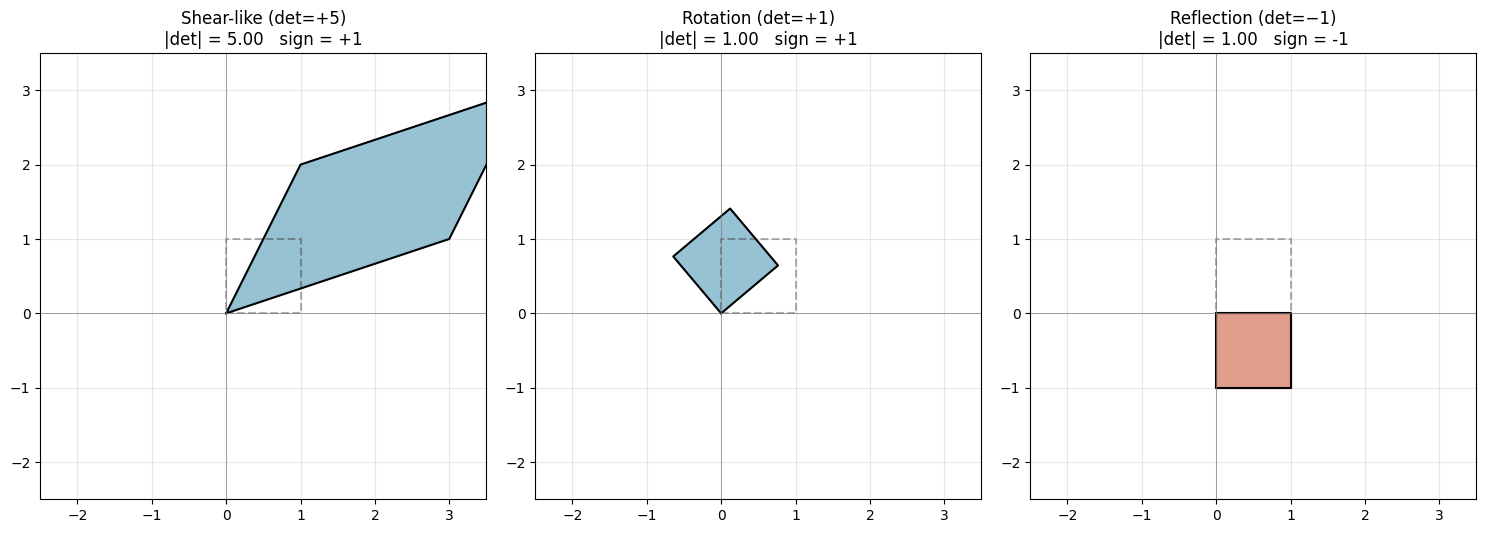

In [6]:
def plot_square_transform(ax, A, title):
    square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
    transformed = A @ square
    det = np.linalg.det(A)
    color = '#2E86AB' if det > 0 else '#C73E1D'
    ax.fill(transformed[0], transformed[1], color=color, alpha=0.5)
    ax.plot(transformed[0], transformed[1], color='k', lw=1.5)
    # unit square outline for reference
    ax.plot(square[0], square[1], 'k--', alpha=0.3)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'{title}\n|det| = {abs(det):.2f}   sign = {np.sign(det):+.0f}')
    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-2.5, 3.5)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_square_transform(axes[0], np.array([[3, 1], [1, 2]]), 'Shear-like (det=+5)')
plot_square_transform(axes[1], np.array([[np.cos(0.7), -np.sin(0.7)],
                                         [np.sin(0.7),  np.cos(0.7)]]), 'Rotation (det=+1)')
plot_square_transform(axes[2], np.array([[1, 0], [0, -1]]), 'Reflection (det=−1)')
plt.tight_layout()
plt.show()

The left panel has area 5 (the parallelogram is spread out). The middle is a rotation — area 1, blue (orientation preserved). The right is a reflection across the x-axis — area 1 but red (orientation reversed, `det = −1`).

## 6. Visualize: 3×3 transformation on the unit cube

Transform the unit cube by `A` with `det A = 16` (from exercise X9) and plot the parallelepiped.

det A = 16.0000   volume = 16.0000


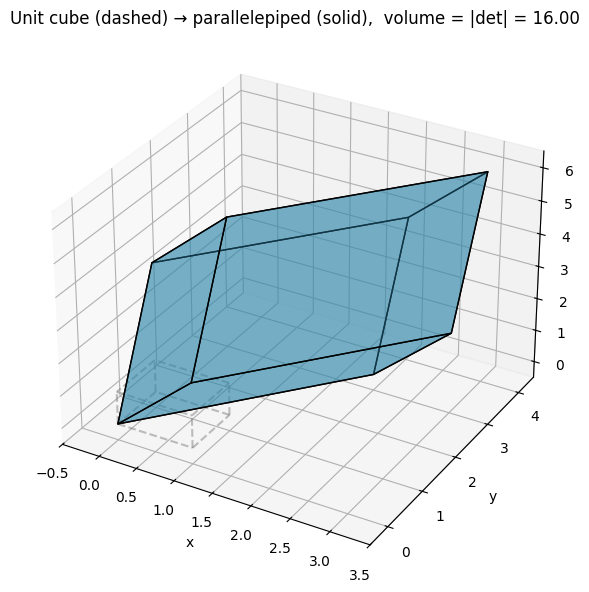

In [7]:
# Unit cube vertices and faces
cube = np.array([
    [0,0,0],[1,0,0],[1,1,0],[0,1,0],  # bottom
    [0,0,1],[1,0,1],[1,1,1],[0,1,1],  # top
], dtype=float)

faces_idx = [
    [0,1,2,3], [4,5,6,7],         # bottom, top
    [0,1,5,4], [2,3,7,6],         # front, back
    [1,2,6,5], [0,3,7,4],         # right, left
]

A = np.array([[1, 2, 0],
              [0, 3, 1],
              [2, 0, 4]], dtype=float)

transformed = cube @ A.T  # cube vertices in rows; matrix acts as A @ point for point as column
det_val = np.linalg.det(A)
print(f'det A = {det_val:.4f}   volume = {abs(det_val):.4f}')

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
poly = [[transformed[i] for i in face] for face in faces_idx]
ax.add_collection3d(Poly3DCollection(
    poly, facecolors='#2E86AB', edgecolors='k', alpha=0.4))

# unit cube wireframe for reference — draw edges as individual lines
edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
for i, j in edges:
    ax.plot3D(*zip(cube[i], cube[j]), color='gray', ls='--', alpha=0.5)

# set limits
all_pts = np.vstack([cube, transformed])
ax.set_xlim(all_pts[:,0].min()-0.5, all_pts[:,0].max()+0.5)
ax.set_ylim(all_pts[:,1].min()-0.5, all_pts[:,1].max()+0.5)
ax.set_zlim(all_pts[:,2].min()-0.5, all_pts[:,2].max()+0.5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(f'Unit cube (dashed) → parallelepiped (solid),  volume = |det| = {abs(det_val):.2f}')
plt.tight_layout()
plt.show()

## 7. Elementary row operations and their effect on `det`

Three operations, three rules: swap flips the sign, scaling multiplies by the scale factor, row addition does nothing. Let's verify numerically.

In [8]:
A = np.array([[2, 1, 3],
              [1, 4, 2],
              [3, 2, 5]], dtype=float)

d0 = np.linalg.det(A)
print(f'det A                        = {d0:.4f}')

# Swap rows 0 and 1
B = A[[1, 0, 2], :]
print(f'det after swap rows 0 and 1  = {np.linalg.det(B):.4f}    (expected {-d0:.4f})')

# Scale row 1 by 5
C = A.copy(); C[1, :] *= 5
print(f'det after scaling row 1 by 5 = {np.linalg.det(C):.4f}   (expected {5*d0:.4f})')

# Add 2·row 0 to row 2
D = A.copy(); D[2, :] += 2 * D[0, :]
print(f'det after adding 2·row 0 to row 2 = {np.linalg.det(D):.4f}   (expected {d0:.4f})')

# det(3A) on 3x3: 27 · det A
print(f'det(3A)                      = {np.linalg.det(3 * A):.4f}   (expected {27*d0:.4f})')

det A                        = 3.0000
det after swap rows 0 and 1  = -3.0000    (expected -3.0000)
det after scaling row 1 by 5 = 15.0000   (expected 15.0000)
det after adding 2·row 0 to row 2 = 3.0000   (expected 3.0000)
det(3A)                      = 81.0000   (expected 81.0000)


## 8. Multiplicativity on random matrices

`det(AB) = det(A) · det(B)` — check on 100 random 5×5 pairs.

In [9]:
errors = []
for _ in range(100):
    A = rng.standard_normal((5, 5))
    B = rng.standard_normal((5, 5))
    lhs = np.linalg.det(A @ B)
    rhs = np.linalg.det(A) * np.linalg.det(B)
    errors.append(abs(lhs - rhs) / max(abs(lhs), 1e-12))

print(f'max relative error over 100 trials: {max(errors):.2e}')

max relative error over 100 trials: 6.32e-14


## 9. Vandermonde closed form

For nodes `x_1, …, x_n`, the Vandermonde matrix has rows `[1, x, x², …, xⁿ⁻¹]` and determinant `∏_{i < j} (x_j − x_i)`. We'll verify on `x = (1, 2, 3, 4, 5)`.

In [10]:
xs = np.array([1, 2, 3, 4, 5], dtype=float)
V = np.vander(xs, increasing=True)      # rows [1, x, x², x³, x⁴]
print('V =\n', V)

prod = 1.0
for i in range(len(xs)):
    for j in range(i+1, len(xs)):
        prod *= (xs[j] - xs[i])

d_np = np.linalg.det(V)
print(f'det V (numpy)     = {d_np:.4f}')
print(f'product formula   = {prod:.4f}')
print(f'match             = {np.isclose(d_np, prod)}')

V =
 [[  1.   1.   1.   1.   1.]
 [  1.   2.   4.   8.  16.]
 [  1.   3.   9.  27.  81.]
 [  1.   4.  16.  64. 256.]
 [  1.   5.  25. 125. 625.]]
det V (numpy)     = 288.0000
product formula   = 288.0000
match             = True


## 10. Cramer's Rule on a 3×3 (worked example E6)

Solve `2x + y + z = 4`, `x + 3y + z = 6`, `x + y + 2z = 5`. Expected: `x = 4/7, y = 9/7, z = 11/7`.

In [11]:
A = np.array([[2, 1, 1],
              [1, 3, 1],
              [1, 1, 2]], dtype=float)
b = np.array([4, 6, 5], dtype=float)

det_A = np.linalg.det(A)
x = np.empty(3)
for i in range(3):
    A_i = A.copy()
    A_i[:, i] = b
    x[i] = np.linalg.det(A_i) / det_A

print(f'Cramer          x = {x}')
print(f'np.linalg.solve x = {np.linalg.solve(A, b)}')
print(f'Expected          = [4/7, 9/7, 11/7] = {np.array([4, 9, 11]) / 7}')

Cramer          x = [0.5714 1.2857 1.5714]
np.linalg.solve x = [0.5714 1.2857 1.5714]
Expected          = [4/7, 9/7, 11/7] = [0.5714 1.2857 1.5714]


## 11. Adjugate and `A · adj(A) = (det A) · I`

For the 3×3 from E7, `A⁻¹ = (1/13) · adj(A)` exactly. We'll compute `adj(A)` via the cofactor formula and verify.

In [12]:
def adjugate(M):
    '''Classical adjoint: transpose of the cofactor matrix.'''
    n = M.shape[0]
    C = np.empty_like(M, dtype=float)
    for i in range(n):
        for j in range(n):
            minor = np.delete(np.delete(M, i, axis=0), j, axis=1)
            C[i, j] = (-1)**(i+j) * np.linalg.det(minor)
    return C.T


A = np.array([[1, 2, 0],
              [0, 1, 3],
              [2, 0, 1]], dtype=float)
det_A = np.linalg.det(A)
adj_A = adjugate(A)
print('det A =', det_A)
print('adj A =\n', adj_A)
print('\nA @ adj(A) =\n', A @ adj_A)
print('\n(det A) I =\n', det_A * np.eye(3))
print('\nmatch:', np.allclose(A @ adj_A, det_A * np.eye(3)))
print('\nA^-1 (via adj) =\n', adj_A / det_A)
print('\nA^-1 (numpy)   =\n', np.linalg.inv(A))

det A = 13.0
adj A =
 [[ 1. -2.  6.]
 [ 6.  1. -3.]
 [-2.  4.  1.]]

A @ adj(A) =
 [[13.  0. -0.]
 [ 0. 13. -0.]
 [ 0.  0. 13.]]

(det A) I =
 [[13.  0.  0.]
 [ 0. 13.  0.]
 [ 0.  0. 13.]]

match: True

A^-1 (via adj) =
 [[ 0.0769 -0.1538  0.4615]
 [ 0.4615  0.0769 -0.2308]
 [-0.1538  0.3077  0.0769]]

A^-1 (numpy)   =
 [[ 0.0769 -0.1538  0.4615]
 [ 0.4615  0.0769 -0.2308]
 [-0.1538  0.3077  0.0769]]


## 12. Eigenvalues as roots of `det(A − λI)`

A preview of Ch 9. For `A = [[4, 1], [2, 3]]`, the characteristic polynomial is `λ² − 7λ + 10 = (λ−2)(λ−5)` — eigenvalues `{2, 5}`.

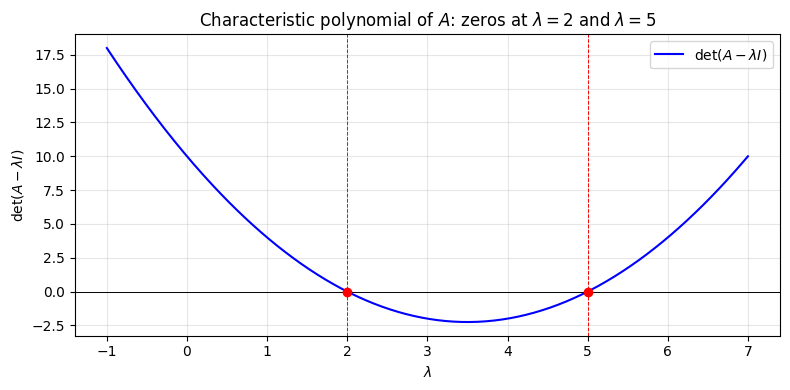

Eigenvalues of A (via numpy): [5. 2.]


In [13]:
A = np.array([[4, 1], [2, 3]], dtype=float)

# Sample det(A - λI) on a grid of λ values and find the roots numerically
lambdas = np.linspace(-1, 7, 400)
vals = np.array([np.linalg.det(A - lam * np.eye(2)) for lam in lambdas])

plt.figure(figsize=(8, 4))
plt.plot(lambdas, vals, 'b-', lw=1.5, label=r'$\det(A - \lambda I)$')
plt.axhline(0, color='k', lw=0.7)
for lam in [2, 5]:
    plt.axvline(lam, color='r', lw=0.7, ls='--')
    plt.plot(lam, 0, 'ro')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\det(A - \lambda I)$')
plt.title(r'Characteristic polynomial of $A$: zeros at $\lambda = 2$ and $\lambda = 5$')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Eigenvalues of A (via numpy):', np.linalg.eigvals(A))

## Takeaways

- **Never compute `det` by the Leibniz formula.** LU is `O(n³)`; cofactor recursion is super-polynomial. `numpy.linalg.det` uses LU under the hood.
- **`det` is a scalar diagnostic** for three distinct properties at once: invertibility (`≠ 0`), volume-scaling magnitude (`|det|`), and orientation (`sign`).
- **Elementary row operations** obey predictable rules — this is the practical computation method by hand.
- **Multiplicativity** `det(AB) = det(A) · det(B)` is the single most useful algebraic property.
- **Cramer's Rule** and **adjugate formula** are theoretical gems; avoid them for numerical computation.
- The characteristic polynomial `det(A − λI)` bridges directly into Ch 9 — eigenvalues and diagonalization.
